# The Family Tree — a quantitative teardown \U0001F52C
### Single linkage · quasi-diagonalisation · recursive bisection · four controls · planted blocks

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Usefulness: Fragile](https://img.shields.io/badge/Usefulness-Fragile-dab617?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The control
that carries this study is **inverse variance** — HRP with the hierarchy deleted. Any advantage
shared with it is an argument for risk-weighting a long-only book, not for clustering, and
separating the two is most of the work.

> ⚠️ **Not investment advice.** Total-return closes from Yahoo! Finance pinned as-of the date
> in [`docs/results.md`](../docs/results.md).
>
> \U0001F4A1 **The `\U0001F4A1 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

In [2]:
from hrp import data, strategy as st

px = data.load_prices()
rets = px.pct_change()
panels = {
    "sectors": [c for c in data.SECTORS if rets[c].notna().sum() > 1500],
    "names": [c for c in data.NAMES if rets[c].notna().sum() > 3000],
    "multi-asset": [c for c in data.MULTI if rets[c].notna().sum() > 3000],
}
print(f"as-of {data.AS_OF}")
for tag, cols in panels.items():
    print(f"  {tag:12s} {len(cols):3d} assets")

as-of 2026-06-30
  sectors       11 assets
  names         40 assets
  multi-asset   10 assets


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| **Signal** | Real | The tree is not decoration: HRP's weights differ from plain inverse-variance weights by **16.7%** of the book on the 40-name panel and 9.3% on the multi-asset one, and the clustering changes the ordering on 3 of 3 panels. What it buys is a different question: HRP holds an effective **26.5** positions against 3.3 for the optimiser, with a maximum weight of 8.4% against 31.6% and no shorts at all. |
| **Usefulness** | Fragile | On the wide panel HRP realises **13.47%** annualised against **13.07%** for minimum variance (paired *t* = -1.01) and **16.20%** for 1/N (*t* = +11.20). Against the control that matters — inverse variance, which is HRP without the tree — the difference is -0.527% (*t* = +6.50). Turnover is 0.27 a rebalance against 1.54, which is where the practical case for it is strongest. |

> \U0001F4A1 **In plain words.** HRP is three good ideas stacked: risk weighting, no shorts,
> and clustering. Two of them are free elsewhere.

## 1 · The claim, decomposed

- **H₁.** The clustering step changes the weights materially versus inverse variance.
- **H₂.** HRP realises lower out-of-sample volatility than minimum variance.
- **H₃.** HRP beats 1/N, which is the benchmark that usually wins.
- **H₄.** The advantage over *inverse variance* — the same method minus the hierarchy — is
  positive. If H₄ fails while H₂ and H₃ hold, the correct conclusion is that risk weighting a
  long-only book is what works, and the tree is decoration.

## 2 · The algorithm, step by step

In [3]:
cols = panels["multi-asset"]
sub = rets[cols].dropna(how="any")
cov = np.cov(sub.iloc[-756:].to_numpy(), rowvar=False, ddof=1)
sd = np.sqrt(np.diag(cov)); corr = cov / np.outer(sd, sd)
d = st.correlation_distance(corr)
links = st.single_linkage(d)
print("first five merges (left, right, distance, size):")
for lk in links[:5]:
    a = cols[lk[0]] if lk[0] < len(cols) else f"cluster{lk[0]}"
    b = cols[lk[1]] if lk[1] < len(cols) else f"cluster{lk[1]}"
    print(f"  {a:6s} + {b:10s} at distance {lk[2]:.3f} -> size {lk[3]}")
order = st.quasi_diagonal_order(links, len(cols))
print("\nquasi-diagonal order:", ", ".join(cols[i] for i in order))
w = st.hrp_weights(cov, order)
print("\nHRP weights:")
print(pd.Series(w, index=cols).round(4).to_string())

first five merges (left, right, distance, size):
  TLT    + IEF        at distance 0.198 -> size 2
  cluster10 + LQD        at distance 0.205 -> size 3
  SPY    + IWM        at distance 0.310 -> size 2
  EFA    + EEM        at distance 0.314 -> size 2
  cluster12 + cluster13  at distance 0.345 -> size 4

quasi-diagonal order: SPY, IWM, EFA, EEM, TLT, IEF, LQD, HYG, GLD, DBC

HRP weights:
SPY   0.0353
IWM   0.0184
EFA   0.0392
EEM   0.0213
TLT   0.0404
IEF   0.1793
LQD   0.1434
HYG   0.4637
GLD   0.0229
DBC   0.0361


## 3 · The teardown

### 3.1 Does the hierarchy move the book?

In [4]:
rows = []
for tag, cs in panels.items():
    s_ = rets[cs].dropna(how="any")
    c = np.cov(s_.iloc[-252:].to_numpy(), rowvar=False, ddof=1)
    w_hrp, w_iv = st.hrp_weights(c), st.inverse_variance_weights(c)
    rows.append({"panel": tag, "assets": len(cs),
                 "share of book moved": np.abs(w_hrp - w_iv).sum() / 2,
                 "max single-name difference": np.abs(w_hrp - w_iv).max(),
                 "corr(HRP, inv-var)": np.corrcoef(w_hrp, w_iv)[0, 1]})
pd.DataFrame(rows).set_index("panel").round(4)

,assets,share of book moved,max single-name difference,"corr(HRP, inv-var)"
panel,,,,
sectors,11,0.0967,0.0311,0.8101
names,40,0.1666,0.0376,0.7752
multi-asset,10,0.0929,0.0856,0.9626


### 3.2 The full scoreboard, three panels

--- sectors ---
             realised_vol  sharpe  turnover  max_weight  effective_n  short
method                                                                     
hrp                0.1499  0.8518    0.1874      0.1941       8.7598 0.0000
min_var            0.1404  0.5969    0.9074      0.6231       1.6411 0.6340
inv_var            0.1503  0.8420    0.1089      0.1722       9.2934 0.0000
risk_parity        0.1535  0.8743    0.0807      0.1401      10.3513 0.0000
equal              0.1604  0.8812    0.0357      0.0909      11.0000 0.0000



--- names ---
             realised_vol  sharpe  turnover  max_weight  effective_n  short
method                                                                     
hrp                0.1347  0.9354    0.2708      0.0843      26.5048 0.0000
min_var            0.1307  0.6468    1.5378      0.3163       3.3011 0.8394
inv_var            0.1400  0.9273    0.1187      0.0669      30.8892 0.0000
risk_parity        0.1451  0.9734    0.0862      0.0521      35.1882 0.0000
equal              0.1620  0.9791    0.0164      0.0250      40.0000 0.0000



--- multi-asset ---
             realised_vol  sharpe  turnover  max_weight  effective_n  short
method                                                                     
hrp                0.0602  0.6610    0.1979      0.3380       4.8602 0.0000
min_var            0.0389  0.6276    0.3945      1.0117       0.7816 0.5397
inv_var            0.0594  0.7238    0.1478      0.3360       4.8172 0.0000
risk_parity        0.1018  0.5469    0.2520      0.2458       6.9967 0.0000
equal              0.0958  0.7126    0.0139      0.1000      10.0000 0.0000



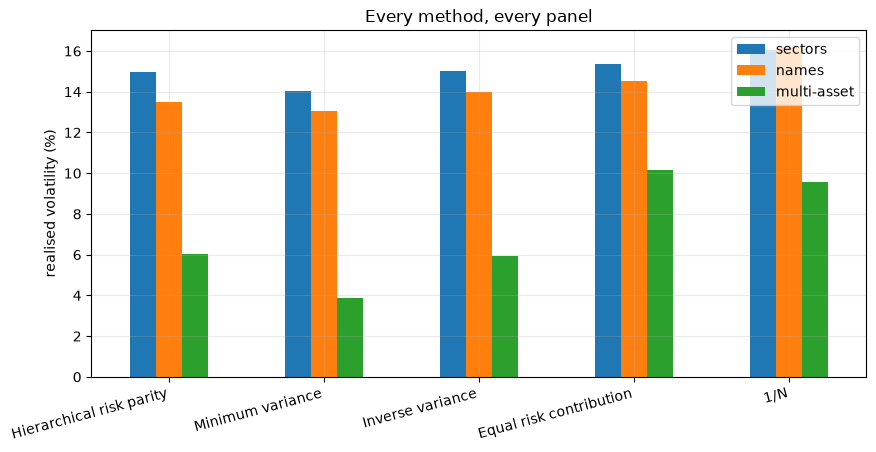

In [5]:
all_wf = {}
for tag, cs in panels.items():
    all_wf[tag] = st.walk_forward(rets[cs].dropna(how="any"), window=252, step=63, cost_bps=5.0)
    print(f"--- {tag} ---")
    print(st.summarise(all_wf[tag])[["realised_vol", "sharpe", "turnover", "max_weight",
                                     "effective_n", "short"]].round(4).to_string())
    print()
vols = pd.DataFrame({tag: st.summarise(wf)["realised_vol"] for tag, wf in all_wf.items()})
vols.index = [st.METHOD_LABEL[m] for m in vols.index]
fig, ax = plt.subplots(figsize=(10, 4.5))
(vols * 100).plot.bar(ax=ax)
ax.set_ylabel("realised volatility (%)"); ax.legend(title="")
ax.set_title("Every method, every panel")
plt.setp(ax.get_xticklabels(), rotation=15, ha="right")
plt.show()

### 3.3 Paired tests — and the control

      panel                      vs  vol diff  t (HRP quieter > 0)  HRP wins  n
    sectors        Minimum variance    0.0095              -1.2828    0.3214 28
    sectors        Inverse variance   -0.0004               0.8729    0.5357 28
    sectors Equal risk contribution   -0.0036               4.3427    0.8214 28
    sectors                     1/N   -0.0104               8.3725    0.9643 28
      names        Minimum variance    0.0040              -1.0145    0.5246 61
      names        Inverse variance   -0.0053               6.5047    0.9016 61
      names Equal risk contribution   -0.0103               8.7890    0.9344 61
      names                     1/N   -0.0273              11.1951    1.0000 61
multi-asset        Minimum variance    0.0213             -12.5884    0.0278 72
multi-asset        Inverse variance    0.0008              -1.5190    0.2778 72
multi-asset Equal risk contribution   -0.0416               7.1637    0.9583 72
multi-asset                     1/N   -0

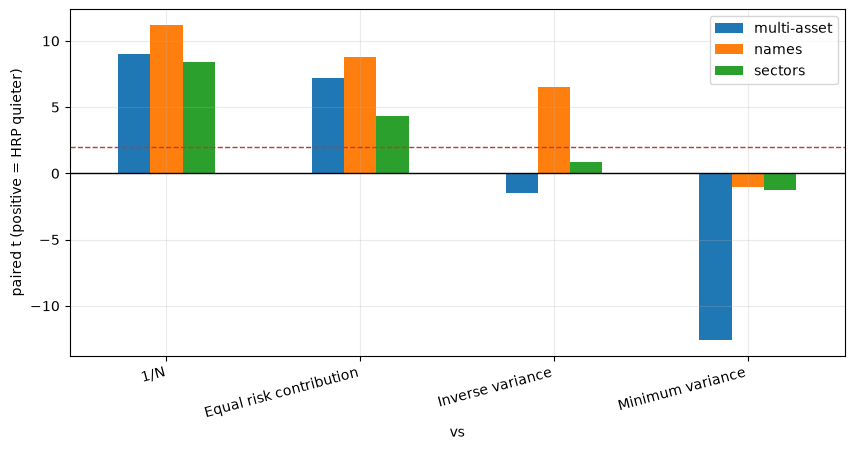

In [6]:
rows = []
for tag, wf in all_wf.items():
    for other in ("min_var", "inv_var", "risk_parity", "equal"):
        p = st.paired_test(wf, "hrp", other)
        rows.append({"panel": tag, "vs": st.METHOD_LABEL[other], "vol diff": p["diff"],
                     "t (HRP quieter > 0)": -p["t"], "HRP wins": p["win_rate"], "n": p["n"]})
d = pd.DataFrame(rows)
print(d.round(4).to_string(index=False))
fig, ax = plt.subplots(figsize=(10, 4.5))
piv = d.pivot(index="vs", columns="panel", values="t (HRP quieter > 0)")
piv.plot.bar(ax=ax)
ax.axhline(0, color="k", lw=1); ax.axhline(2, color="#c0392b", ls="--", lw=1)
ax.set_ylabel("paired t (positive = HRP quieter)"); ax.legend(title="")
plt.setp(ax.get_xticklabels(), rotation=15, ha="right")
plt.show()

> \U0001F4A1 **In plain words.** Read the `Inverse variance` row first. That is HRP minus the
> tree. Whatever HRP achieves that inverse variance does not is the value of the hierarchy;
> everything else is the value of not shorting and of weighting by risk.

### 3.4 Stability of the weights

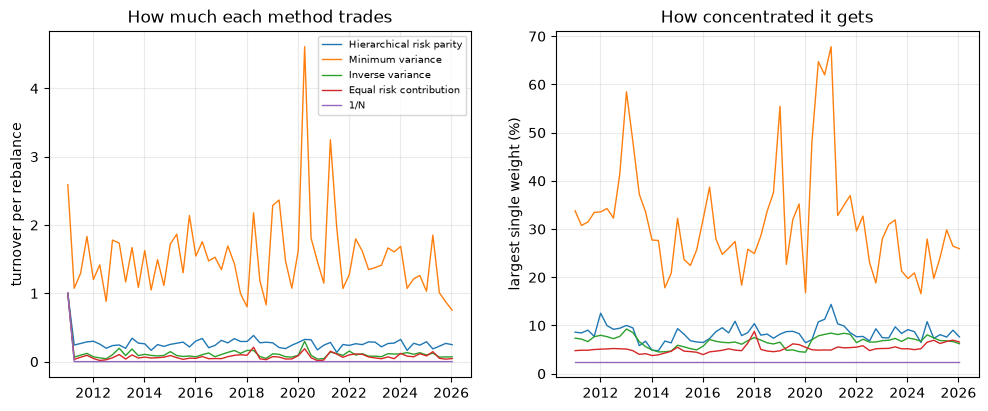

method   equal     hrp  inv_var  min_var  risk_parity
count  61.0000 61.0000  61.0000  61.0000      61.0000
mean    0.0160  0.2710   0.1190   1.5380       0.0860
std     0.1280  0.1060   0.1220   0.6100       0.1250
min     0.0000  0.1350   0.0370   0.7530       0.0150
25%     0.0000  0.2370   0.0740   1.1490       0.0440
50%     0.0000  0.2650   0.0970   1.4680       0.0640
75%     0.0000  0.2890   0.1210   1.7350       0.0920
max     1.0000  1.0000   1.0000   4.6120       1.0000


In [7]:
wf = all_wf["names"]
piv = wf.pivot(index="date", columns="method", values="turnover")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for m in st.METHODS:
    axes[0].plot(piv.index, piv[m], lw=1, label=st.METHOD_LABEL[m])
axes[0].set_ylabel("turnover per rebalance"); axes[0].legend(fontsize=7)
axes[0].set_title("How much each method trades")
mw = wf.pivot(index="date", columns="method", values="max_weight")
for m in st.METHODS:
    axes[1].plot(mw.index, mw[m] * 100, lw=1, label=st.METHOD_LABEL[m])
axes[1].set_ylabel("largest single weight (%)"); axes[1].set_title("How concentrated it gets")
plt.show()
print(piv.describe().round(3).to_string())

### 3.5 Monte Carlo with planted structure

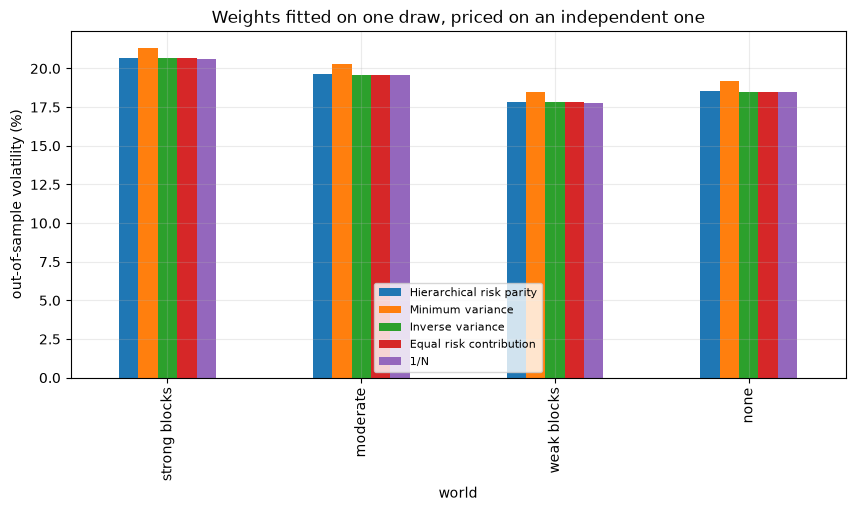

,Hierarchical risk parity,Minimum variance,Inverse variance,Equal risk contribution,1/N
world,,,,,
strong blocks,0.2067,0.2134,0.2065,0.2065,0.2064
moderate,0.1964,0.2029,0.1961,0.1961,0.1960
weak blocks,0.1781,0.1846,0.1781,0.1781,0.1780
none,0.1852,0.1918,0.1849,0.1849,0.1848


In [8]:
rows = []
for rho_in, rho_out, tag in ((0.7, 0.1, "strong blocks"), (0.5, 0.2, "moderate"),
                             (0.3, 0.25, "weak blocks"), (0.3, 0.3, "none")):
    acc = {m: [] for m in st.METHODS}
    for seed in range(10):
        X, _ = st.block_panel(n_per_block=10, n_blocks=2, n_obs=250, rho_in=rho_in,
                              rho_out=rho_out, seed=976 + seed)
        Y, _ = st.block_panel(n_per_block=10, n_blocks=2, n_obs=250, rho_in=rho_in,
                              rho_out=rho_out, seed=7000 + seed)
        cov_hat = np.cov(X, rowvar=False, ddof=1)
        for m in st.METHODS:
            acc[m].append(np.std(Y @ st.weights_for(m, cov_hat), ddof=1) * np.sqrt(252))
    rows.append({"world": tag, **{st.METHOD_LABEL[m]: float(np.mean(v)) for m, v in acc.items()}})
d = pd.DataFrame(rows).set_index("world")
fig, ax = plt.subplots(figsize=(10, 4.5))
(d * 100).plot.bar(ax=ax)
ax.set_ylabel("out-of-sample volatility (%)"); ax.legend(title="", fontsize=8)
ax.set_title("Weights fitted on one draw, priced on an independent one")
plt.show()
d.round(4)

### 3.6 Window sensitivity

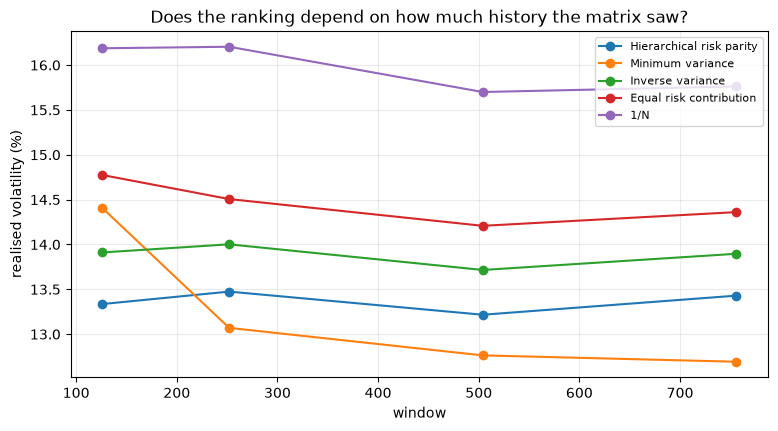

,Hierarchical risk parity,Minimum variance,Inverse variance,Equal risk contribution,1/N
window,,,,,
126,0.1334,0.1441,0.1391,0.1477,0.1619
252,0.1347,0.1307,0.1400,0.1451,0.1620
504,0.1322,0.1276,0.1372,0.1421,0.1570
756,0.1343,0.1269,0.1390,0.1436,0.1576


In [9]:
rows = []
sub = rets[panels["names"]].dropna(how="any")
for w in (126, 252, 504, 756):
    s = st.summarise(st.walk_forward(sub, window=w, step=63, cost_bps=5.0))
    rows.append({"window": w, **{st.METHOD_LABEL[m]: s.loc[m, "realised_vol"]
                                 for m in st.METHODS}})
d = pd.DataFrame(rows).set_index("window")
fig, ax = plt.subplots(figsize=(9, 4.5))
(d * 100).plot(ax=ax, marker="o")
ax.set_ylabel("realised volatility (%)"); ax.legend(fontsize=8, title="")
ax.set_title("Does the ranking depend on how much history the matrix saw?")
plt.show()
d.round(4)

## 4 · The verdict

In [10]:
summary = {}
for tag, wf in all_wf.items():
    s = st.summarise(wf)
    summary[tag] = {
        "HRP vol": s.loc["hrp", "realised_vol"],
        "min-var vol": s.loc["min_var", "realised_vol"],
        "inv-var vol": s.loc["inv_var", "realised_vol"],
        "1/N vol": s.loc["equal", "realised_vol"],
        "t vs min-var": -st.paired_test(wf, "hrp", "min_var")["t"],
        "t vs inv-var": -st.paired_test(wf, "hrp", "inv_var")["t"],
        "t vs 1/N": -st.paired_test(wf, "hrp", "equal")["t"],
    }
pd.DataFrame(summary).T.round(4)

,HRP vol,min-var vol,inv-var vol,1/N vol,t vs min-var,t vs inv-var,t vs 1/N
sectors,0.1499,0.1404,0.1503,0.1604,-1.2828,0.8729,8.3725
names,0.1347,0.1307,0.1400,0.1620,-1.0145,6.5047,11.1951
multi-asset,0.0602,0.0389,0.0594,0.0958,-12.5884,-1.5190,9.0337


## 5 · Going further

- **HRP on a shrunk covariance matrix**: the two remedies are not exclusive, and stacking them
  is the obvious experiment neither literature runs.
- **Nested clustered optimisation** (López de Prado 2019) is the successor, and it does invert
  matrices — inside clusters, where they are small and well conditioned.
- **Ward or average linkage**, and correlation distances built on tail dependence rather than
  Pearson correlation.